In [1]:
# The sparse fit over the region never passed a check it was never given. This runs the first rung
# of ptgp's own ladder: the same objective and the same priors with the sparsification taken away,
# on ground small enough that the inducing points can cover it.
#
# Tier A as written assumes a Gaussian likelihood and a marginal log-likelihood, which an aggregated
# Poisson does not have. What carries over is the point of it -- if the model is wrong, no choice of
# inducing points rescues it, so remove the approximation rather than the likelihood.
%load_ext autoreload
%autoreload 1
%aimport svgp_support

import pytensor

pytensor.config.floatX = "float32"

import re

from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np
import pandas as pd
import polars as pl
import preliz as pz
import ptgp
import pytensor.tensor as pt

from ptgp.inducing import compute_inducing_diagnostics, greedy_variance_init
from ptgp.kernels import Matern32

from climate_risk.config.registry import load_place
from climate_risk.data.gadm import load_units_in_country
from climate_risk.data.ghsl import population_on_cells
from climate_risk.data.model_frame import event_windows
from climate_risk.data.placement import resolve_location_text
from climate_risk.data_functions.emdat_processing import event_filter, event_geography, load_emdat_events
from climate_risk.data_functions.rivers_data_loader import load_rivers_data
from climate_risk.data_functions.shapefiles_data_loader import load_place_boundary, load_shapefile
from climate_risk.geo.crs import to_km
from climate_risk.geo.distance import get_distance_to
from climate_risk.geo.raster import assign_cells_to_units, build_cell_grid
from climate_risk.models.aggregation import build_aggregation, build_aggregation_from_overlaps
from climate_risk.plotting import configure_plot_style
from svgp_support import (
    RIVER_FLOW,
    TO_COAST,
    TO_RIVER,
    YEAR,
    annealed_adam,
    build_model_2,
    fit_minibatch,
    save_fit,
    select_inducing,
    standardized,
)

FLOATX = pytensor.config.floatX

pz.rcParams["plots.show_plot"] = False
configure_plot_style()

In [31]:
CACHE = (Path.cwd().parents[1] if Path.cwd().name == "geo_damage_model" else Path.cwd()) / "data"
FITS_DIR = Path.cwd() / "fits"

PLACE_KEY = "sea"
RESOLUTION_KM = 10.0
EPOCH = 2020
ATOM_LEVEL = 2
HAZARD_CLASS = "Hydrometereological"

# Vietnam, not Laos. Laos is landlocked, so distance to coast there is distance to a sea the country
# never reaches -- a smooth gradient carrying nothing, and the coast surface duly switched itself
# off. A country with a coastline gives both surfaces something to explain, which is what a test of
# the model rather than of one country's geography needs.
COUNTRY = "VNM"

place = load_place(PLACE_KEY)
boundary = load_place_boundary(place, CACHE)
grid = build_cell_grid(boundary, resolution_km=RESOLUTION_KM)
lon, lat = grid.cells["lon"].to_numpy(), grid.cells["lat"].to_numpy()
people = population_on_cells(grid, EPOCH, CACHE)

pd.Series(
    {
        "cells over the region": float(len(grid.cells)),
        "people (millions)": people.sum() / 1e6,
    },
    name="value",
).to_frame().round(1)

,value
cells over the region,50667.00
people (millions),642.00


In [32]:
rivers = load_rivers_data(CACHE)
coastline = load_shapefile("coastline", CACHE)

margin, simplify_degrees = 12.0, 0.5 / 111.0
west, south, east, north = grid.cells.total_bounds
longitudes = slice(west - margin, east + margin)
latitudes = slice(south - margin, north + margin)

nearby_rivers = rivers.cx[longitudes, latitudes].copy()
nearby_rivers["geometry"] = nearby_rivers.simplify(simplify_degrees)
nearby_coast = coastline.cx[longitudes, latitudes].boundary.simplify(simplify_degrees)

nearest_river = get_distance_to(nearby_rivers, points=grid.cells, return_columns=["DIS_AV_CMS"])
to_river = to_km(nearest_river["distance_to_closest"])
river_flow = nearest_river["DIS_AV_CMS"]
to_coast = to_km(get_distance_to(nearby_coast, points=grid.cells)["distance_to_closest"])

units = pd.concat(
    [load_units_in_country(iso=iso, level=ATOM_LEVEL, cache_dir=CACHE) for iso in place.members],
    ignore_index=True,
)
units = gpd.GeoDataFrame(units, crs="EPSG:4326")

EQUAL_AREA_CRS = "EPSG:6933"
units["area_km2"] = units.to_crs(EQUAL_AREA_CRS).area / 1e6

coverage = assign_cells_to_units(grid, units)
cell_of_overlap = grid.column_of_cell(coverage["cell_id"].to_numpy())

covered = np.zeros(len(grid.cells))
np.add.at(covered, cell_of_overlap, coverage["coverage"].to_numpy())
share = coverage["coverage"].to_numpy() / covered[cell_of_overlap] * people[cell_of_overlap]

CARRIED_COLUMNS = ("lon", "lat", "to_river", "to_coast", "river_flow")

carried = pd.DataFrame(
    {
        "gid": coverage["gid"].to_numpy(),
        "people": share,
        "lon": share * lon[cell_of_overlap],
        "lat": share * lat[cell_of_overlap],
        "to_river": share * to_river.to_numpy()[cell_of_overlap],
        "to_coast": share * to_coast.to_numpy()[cell_of_overlap],
        "river_flow": share * river_flow.to_numpy()[cell_of_overlap],
    }
).groupby("gid", as_index=False).sum()

atoms_all = carried[carried["people"] > 0].reset_index(drop=True)
for column in CARRIED_COLUMNS:
    atoms_all[column] /= atoms_all["people"]
atoms_all = atoms_all.merge(units[["gid", "area_km2"]].drop_duplicates("gid"), on="gid", how="left")

# The one country, and only it.
atoms = atoms_all[atoms_all["gid"].str.startswith(f"{COUNTRY}.")].reset_index(drop=True)

pd.Series(
    {
        "atoms over the region": float(len(atoms_all)),
        f"atoms in {COUNTRY}": float(len(atoms)),
        "people (millions)": float(atoms["people"].sum() / 1e6),
        "area (thousand km2)": float(atoms["area_km2"].sum() / 1e3),
        "median unit area (km2)": float(atoms["area_km2"].median()),
    },
    name="value",
).to_frame().round(2)

,value
atoms over the region,4387.00
atoms in VNM,706.00
people (millions),94.71
area (thousand km2),329.22
median unit area (km2),324.49


In [33]:
workbook = load_emdat_events(CACHE)
events = workbook.filter(
    event_filter(place.events)
    & (pl.col("ISO") == COUNTRY)
    & (pl.col("disaster_class") == HAZARD_CLASS)
)

from_text, text_resolution = resolve_location_text(events, CACHE)
geography = event_geography(events, from_text=from_text, text_resolution=text_resolution)
windows = event_windows(events, geography)

VERSION_SUFFIX = re.compile(r"_\d+$")


def stem_of(gid: str) -> str:
    return VERSION_SUFFIX.sub("", gid)


stems = [stem_of(gid) for gid in atoms["gid"]]
row_of_stem = {stem: row for row, stem in enumerate(stems)}

children_of = {}
for row, stem in enumerate(stems):
    children_of.setdefault(stem.rsplit(".", 1)[0], []).append(row)


def atoms_of(gid: str, level: int) -> list[int]:
    """Rows of ``atoms`` the named unit dissolves into."""
    stem = stem_of(gid)

    if level < ATOM_LEVEL:
        return children_of.get(stem, [])

    ancestor = stem
    for _ in range(level - ATOM_LEVEL):
        ancestor = ancestor.rsplit(".", 1)[0]
    row = row_of_stem.get(ancestor)

    return [] if row is None else [row]


years = np.arange(windows["year"].min(), windows["year"].max() + 1)
n_atoms, n_years = len(atoms), len(years)
year_index = {year: position for position, year in enumerate(years)}
year_of_event = dict(zip(windows["DisNo."], windows["year"], strict=True))

named_by_event = {}
for disno, gid, level in geography.select("DisNo.", "gid", "admin_level").drop_nulls().iter_rows():
    named_by_event.setdefault(disno, []).extend(atoms_of(gid, level))

event_ids = windows["DisNo."].to_list()
every_atom = list(range(n_atoms))

unit_of_overlap, columns = [], []
for disno in event_ids:
    reached = named_by_event.get(disno) or every_atom
    offset = year_index[year_of_event[disno]] * n_atoms
    for row in set(reached):
        unit_of_overlap.append(disno)
        columns.append(row + offset)

columns = np.array(columns)
atom_people = atoms["people"].to_numpy()
atom_area = atoms["area_km2"].to_numpy()

observations = build_aggregation_from_overlaps(
    unit_of_overlap=unit_of_overlap,
    cell_of_overlap=columns,
    weights=atom_area[columns % n_atoms],
    n_cells=n_atoms * n_years,
    units=event_ids,
)

atoms_per_event = np.diff(observations.matrix.tocsr().indptr)
pd.Series(
    {
        "atoms": float(n_atoms),
        "years": float(n_years),
        "atom-years": float(n_atoms * n_years),
        "events": float(observations.n_units),
        "events reaching no atom": float((atoms_per_event == 0).sum()),
        "atoms per event, median": float(np.median(atoms_per_event)),
        "atoms per event, largest": float(atoms_per_event.max()),
        "events seen through the whole country": float((atoms_per_event == n_atoms).sum()),
    },
    name="value",
).to_frame()

,value
atoms,706.00
years,45.00
atom-years,31770.00
events,258.00
events reaching no atom,0.00
"atoms per event, median",52.00
"atoms per event, largest",706.00
events seen through the whole country,18.00


In [48]:
POPULATION_FLOOR = 1.0

log_people = np.log(np.maximum(atom_people, POPULATION_FLOOR))

# Every axis standardized. The year mattered most: a Matern takes squared distances through
# |x|^2 + |y|^2 - 2xy, and at values near two thousand the first two terms are around four million,
# where single precision spaces its representable numbers a quarter apart -- against true squared
# distances of order twenty. The kernel entries came out wrong in the third decimal, which was
# enough to carry the smallest eigenvalues of K(Z, Z) below zero and take the factorization down.
#
# The scales are kept so the fit reads in the units it was posed in, and so the lengthscale priors
# can be carried across unchanged rather than reinvented: standardizing an axis changes what a
# number on it means, not what is believed about it.
YEAR_ORIGIN, YEAR_SCALE = float(np.mean(years)), float(np.std(years))
POPULATION_ORIGIN, POPULATION_SCALE = float(np.mean(log_people)), float(np.std(log_people))

features = np.column_stack(
    [
        np.repeat((years - YEAR_ORIGIN) / YEAR_SCALE, n_atoms),
        np.tile(standardized(np.log1p(atoms["to_river"].to_numpy())), n_years),
        np.tile(standardized(np.log1p(atoms["to_coast"].to_numpy())), n_years),
        np.tile(standardized(np.log(atoms["river_flow"].to_numpy())), n_years),
        np.tile((log_people - POPULATION_ORIGIN) / POPULATION_SCALE, n_years),
    ]
).astype(FLOATX)

N_KERNEL_DIMS = 4

# The intervals as they were, in the units the axes now carry. The covariates were already
# standardized, so theirs is unchanged; the temporal one was in years and is divided through.
COVARIATE_BOUNDS = (0.5, 5.0)
TEMPORAL_BOUNDS = (2.0 / YEAR_SCALE, 20.0 / YEAR_SCALE)

weights = np.tile(atom_area, n_years).astype(FLOATX)
region = build_aggregation(unit_of_cell=["region"] * len(features), weights=weights)


def prior_kernel(covariate_ls=2.3, temporal_ls=9.2 / 12.99, amplitude=0.57):
    """The two Matern surfaces at plausible hyperparameters, for judging a set of inducing points."""
    return amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([covariate_ls, covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
    ) + amplitude**2 * Matern32(
        input_dim=features.shape[1],
        ls=np.array([covariate_ls, temporal_ls], dtype=FLOATX),
        active_dims=[TO_COAST, YEAR],
    )


pd.Series(
    {
        "atom-years": float(len(features)),
        "every column has sd one": float(np.allclose(features.std(axis=0), 1.0, atol=0.02)),
        "largest absolute feature value": float(np.abs(features).max()),
        "year scale (years per sd)": YEAR_SCALE,
        "population scale (logs per sd)": POPULATION_SCALE,
        "temporal interval, in sd": TEMPORAL_BOUNDS[0],
        "temporal interval upper, in sd": TEMPORAL_BOUNDS[1],
    },
    name="value",
).to_frame().round(3)

,value
atom-years,31770.00
every column has sd one,1.00
largest absolute feature value,4.55
year scale (years per sd),12.99
population scale (logs per sd),0.75
"temporal interval, in sd",0.15
"temporal interval upper, in sd",1.54


In [49]:
# choosing_M: run greedy once past what you need, then read the knee off the trace curve, requiring
# residual variance under about 1%. Picking M because it happens to factor is how notebook 02 ended
# up at 250 with 2.2% residual.
M_MAX = 1024

inducing_max, diagnostics = greedy_variance_init(features, M_MAX, prior_kernel())
print(repr(diagnostics))
print()
print("fields:", ", ".join(sorted(f for f in vars(diagnostics) if not f.startswith("_"))))

M                 : 1024
variance explained: 99.6%
min eigenvalue    : 0.00128
max eigenvalue    : 182
condition number  : 1.42e+05
eigs < 1e-04     : 0

fields: d_final, kuu_condition_number, kuu_eig_threshold, kuu_max_eigenvalue, kuu_min_eigenvalue, kuu_n_small_eigenvalues, total_variance, trace_curve


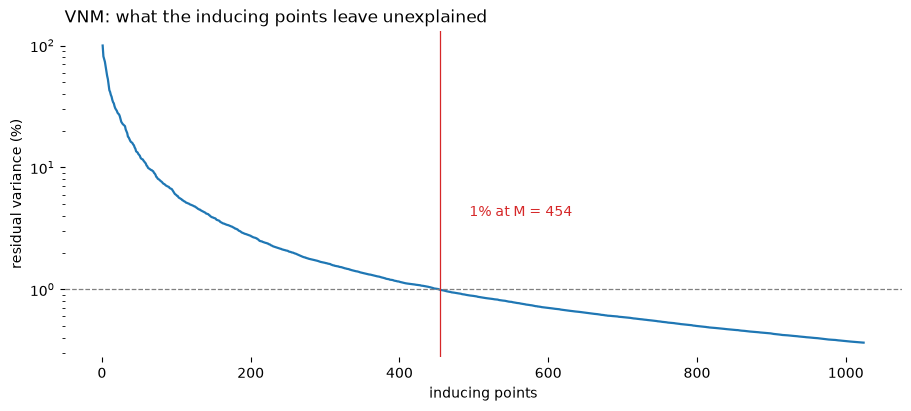

,value
atom-years,31770.00
M where residual falls below 1%,454.00
that M as a share of the lattice (%),1.43
residual at M=250 (%),2.07
residual at M=1024 (%),0.37


In [50]:
residual = np.asarray(diagnostics.trace_curve) / float(diagnostics.total_variance)
inducing_counts = np.arange(1, len(residual) + 1)

below_one_percent = int(inducing_counts[residual < 0.01][0]) if (residual < 0.01).any() else None

figure, ax = plt.subplots(figsize=(9, 4))

ax.plot(inducing_counts, 100 * residual, color="C0", linewidth=1.6)
ax.axhline(1.0, color="0.5", linestyle="--", linewidth=0.9)
if below_one_percent is not None:
    ax.axvline(below_one_percent, color="C3", linewidth=0.9)
    ax.annotate(
        f"1% at M = {below_one_percent}",
        xy=(below_one_percent, 1.0),
        xytext=(below_one_percent + 40, 4.0),
        color="C3",
    )

ax.set_yscale("log")
ax.set_xlabel("inducing points")
ax.set_ylabel("residual variance (%)")
ax.set_title(f"{COUNTRY}: what the inducing points leave unexplained", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

pd.Series(
    {
        "atom-years": float(len(features)),
        "M where residual falls below 1%": float(below_one_percent if below_one_percent else np.nan),
        "that M as a share of the lattice (%)": 100 * (below_one_percent or np.nan) / len(features),
        "residual at M=250 (%)": 100 * float(residual[249]),
        "residual at M=1024 (%)": 100 * float(residual[-1]),
    },
    name="value",
).to_frame().round(3)

In [8]:
from ptgp.optim.training import compile_scipy_objective
from ptgp.utils import check_init

from climate_risk.models.areal import windowed_poisson_elbo
from svgp_support import poisson_intercept

M_EXACT = 1024

counts = np.ones(observations.n_units, dtype=FLOATX)
inducing = select_inducing(features, M_EXACT, prior_kernel())[:, :N_KERNEL_DIMS]

check_model, check_svgp = build_model_2(
    features,
    inducing,
    intercept_init=poisson_intercept(float(counts.sum()), float(region.weights.sum())),
)

with check_model:

    def objective(gp, batch_features, window_counts):
        return windowed_poisson_elbo(gp, batch_features, window_counts, observations, region)

    loss_and_grad, theta0, _, _, _ = compile_scipy_objective(
        objective,
        check_svgp,
        pt.matrix("X", shape=(None, features.shape[1])),
        pt.vector("y", shape=(None,)),
        model=check_model,
        compile_kwargs={"mode": "FAST_RUN"},
    )

# The pre-flight from Tier B: a non-finite loss or a huge gradient here is a problem with the model
# or the priors, and no amount of optimizer work will fix it.
check_init(loss_and_grad, theta0, features, counts, model=check_model)

loss at init : nan  (NaN/Inf -- BAD)
grad finite  : False  (max |g| = nan)

top-10 |grad| components:
  [525832]  nan   525832
  [175362]  nan   175362
  [175268]  nan   175268
  [175269]  nan   175269
  [175270]  nan   175270
  [175271]  nan   175271
  [175272]  nan   175272
  [175273]  nan   175273
  [175274]  nan   175274
  [175275]  nan   175275


False

In [9]:
initial = check_model.initial_point()
per_term = check_model.compile_logp(sum=False)(initial)

pd.DataFrame(
    {
        "shape at init": {v.name: str(np.shape(initial[v.name])) for v in check_model.continuous_value_vars},
        "prior logp": {
            rv.name: float(np.sum(value))
            for rv, value in zip(check_model.basic_RVs, per_term, strict=True)
        },
    }
)

,shape at init,prior logp
intercept,(),-2.65
hydro_amplitude_log__,(),NaN
hydro_lengthscale_to_river_log__,(),NaN
hydro_lengthscale_river_flow_log__,(),NaN
hydro_lengthscale_year_log__,(),NaN
coast_amplitude_log__,(),NaN
coast_lengthscale_to_coast_log__,(),NaN
coast_lengthscale_year_log__,(),NaN
population_exponent_logodds__,(),NaN
country_offsets,"(0,)",0.00


In [10]:
# One country leaves the linear predictor with a single column, so build_model_2 makes
# country_offsets zero-length and dots it against an empty slice. A dummy second column removes
# that without changing the model: its coefficient multiplies zeros.
padded_features = np.column_stack([features, np.zeros(len(features))]).astype(FLOATX)

padded_model, padded_svgp = build_model_2(
    padded_features,
    inducing,
    intercept_init=poisson_intercept(float(counts.sum()), float(region.weights.sum())),
)

with padded_model:

    def padded_objective(gp, batch_features, window_counts):
        return windowed_poisson_elbo(gp, batch_features, window_counts, observations, region)

    padded_loss_and_grad, padded_theta0, _, _, _ = compile_scipy_objective(
        padded_objective,
        padded_svgp,
        pt.matrix("X", shape=(None, padded_features.shape[1])),
        pt.vector("y", shape=(None,)),
        model=padded_model,
        compile_kwargs={"mode": "FAST_RUN"},
    )

check_init(padded_loss_and_grad, padded_theta0, padded_features, counts, model=padded_model)

loss at init : nan  (NaN/Inf -- BAD)
grad finite  : False  (max |g| = nan)

top-10 |grad| components:
  [525833]  nan   525833
  [175363]  nan   175363
  [175269]  nan   175269
  [175270]  nan   175270
  [175271]  nan   175271
  [175272]  nan   175272
  [175273]  nan   175273
  [175274]  nan   175274
  [175275]  nan   175275
  [175276]  nan   175276


False

In [11]:
from collections import namedtuple

from ptgp.optim.training import compile_scipy_diagnostics

from climate_risk.models.aggregated_poisson import expected_intensity, latent_moments, mean_log_intensity

ExactTerms = namedtuple(
    "ExactTerms",
    "elbo window_term region_term kl smallest_log_intensity largest_absolute_mean "
    "smallest_independent_variance largest_independent_variance largest_absolute_factor "
    "smallest_kernel_diagonal",
)


def exact_terms(gp, cell_features, window_counts):
    """windowed_poisson_elbo, opened up."""
    moments = latent_moments(gp, cell_features)
    mean, independent_variance, factor = moments

    log_intensity = mean_log_intensity(gp, observations, moments)
    over_the_region = expected_intensity(region, *moments)

    window_term = pt.sum(window_counts * log_intensity)
    region_term = pt.sum(over_the_region)
    kl = gp.prior_kl()

    return ExactTerms(
        elbo=window_term - region_term - kl,
        window_term=window_term,
        region_term=region_term,
        kl=kl,
        smallest_log_intensity=pt.min(log_intensity),
        largest_absolute_mean=pt.max(pt.abs(mean)),
        smallest_independent_variance=pt.min(independent_variance),
        largest_independent_variance=pt.max(independent_variance),
        largest_absolute_factor=pt.max(pt.abs(factor)),
        smallest_kernel_diagonal=pt.min(gp.kernel.diag(cell_features)),
    )


with check_model:
    evaluate_exact = compile_scipy_diagnostics(
        exact_terms,
        check_svgp,
        pt.matrix("X", shape=(None, features.shape[1])),
        pt.vector("y", shape=(None,)),
        model=check_model,
        compile_kwargs={"mode": "FAST_RUN"},
    )

readings = np.asarray(evaluate_exact(theta0, features, counts), dtype=float)
pd.Series(dict(zip(ExactTerms._fields, readings, strict=True)), name="value").to_frame()

,value
elbo,NaN
window_term,NaN
region_term,NaN
kl,0.00
smallest_log_intensity,NaN
largest_absolute_mean,NaN
smallest_independent_variance,NaN
largest_independent_variance,NaN
largest_absolute_factor,NaN
smallest_kernel_diagonal,0.65


In [12]:
from ptgp.utils import get_initial_params

# The kernel the fit actually starts from, rather than the one prior_kernel() guesses at. The
# bad_priors check is only meaningful on this matrix.
median = get_initial_params(check_model, init="prior_median")
median_values = {name: float(np.asarray(value)) for name, value in median.items() if np.size(value) == 1}

median_kernel = median_values["hydro_amplitude"] ** 2 * Matern32(
    input_dim=features.shape[1],
    ls=np.array(
        [
            median_values["hydro_lengthscale_to_river"],
            median_values["hydro_lengthscale_river_flow"],
            median_values["hydro_lengthscale_year"],
        ],
        dtype=FLOATX,
    ),
    active_dims=[TO_RIVER, RIVER_FLOW, YEAR],
) + median_values["coast_amplitude"] ** 2 * Matern32(
    input_dim=features.shape[1],
    ls=np.array(
        [median_values["coast_lengthscale_to_coast"], median_values["coast_lengthscale_year"]], dtype=FLOATX
    ),
    active_dims=[TO_COAST, YEAR],
)

padded_inducing = np.column_stack([inducing, np.zeros((len(inducing), features.shape[1] - N_KERNEL_DIMS))]).astype(FLOATX)
_left, _right = pt.matrix("left"), pt.matrix("right")
Kuu_median = np.asarray(
    pytensor.function([_left, _right], median_kernel(_left, _right))(padded_inducing, padded_inducing),
    dtype=np.float64,
)
spectrum = np.linalg.eigvalsh(Kuu_median)
ridge = 10.0 * np.finfo(np.float32).eps * len(Kuu_median) * np.mean(np.diag(Kuu_median))

pd.DataFrame(
    {
        "prior median": {k: round(v, 4) for k, v in median_values.items()},
        "what prior_kernel() assumed": {
            "hydro_amplitude": 0.57,
            "coast_amplitude": 0.57,
            "hydro_lengthscale_to_river": 2.3,
            "hydro_lengthscale_river_flow": 2.3,
            "hydro_lengthscale_year": 9.2,
            "coast_lengthscale_to_coast": 2.3,
            "coast_lengthscale_year": 9.2,
        },
    }
).join(
    pd.DataFrame(
        {
            "Kuu at the prior median": {
                "smallest eigenvalue": spectrum.min(),
                "largest eigenvalue": spectrum.max(),
                "condition number": spectrum.max() / abs(spectrum.min()),
                "ridge available": ridge,
                "cholesky survives": float(ridge + spectrum.min() > 0),
            }
        }
    ),
    how="outer",
)

,prior median,what prior_kernel() assumed,Kuu at the prior median
cholesky survives,NaN,NaN,0.00
coast_amplitude,0.57,0.57,NaN
coast_lengthscale_to_coast,2.30,2.30,NaN
coast_lengthscale_year,9.18,9.20,NaN
condition number,NaN,NaN,13298.91
hydro_amplitude,0.57,0.57,NaN
hydro_lengthscale_river_flow,2.30,2.30,NaN
hydro_lengthscale_to_river,2.30,2.30,NaN
hydro_lengthscale_year,9.18,9.20,NaN
intercept,-12.44,NaN,NaN


In [51]:
# The knee, not a round number chosen for sounding exact. 350 is where residual variance falls
# below 1%; 1024 asks for more directions than this lattice supports.
M_EXACT = int(below_one_percent)

counts = np.ones(observations.n_units, dtype=FLOATX)
inducing = select_inducing(features, M_EXACT, prior_kernel())[:, :N_KERNEL_DIMS]

padded_inducing = np.column_stack(
    [inducing, np.zeros((len(inducing), features.shape[1] - N_KERNEL_DIMS))]
).astype(FLOATX)
Kuu_here = np.asarray(
    pytensor.function([_left, _right], median_kernel(_left, _right))(padded_inducing, padded_inducing),
    dtype=np.float64,
)
spectrum_here = np.linalg.eigvalsh(Kuu_here)
ridge_here = 10.0 * np.finfo(np.float32).eps * len(Kuu_here) * np.mean(np.diag(Kuu_here))

print(f"M = {M_EXACT}, {100 * M_EXACT / len(features):.1f}% of the lattice")
print(f"  smallest eigenvalue : {spectrum_here.min():+.4e}")
print(f"  condition number    : {spectrum_here.max() / abs(spectrum_here.min()):.3g}")
print(f"  cholesky survives   : {bool(ridge_here + spectrum_here.min() > 0)}")
print()

check_model, check_svgp = build_model_2(
    features,
    inducing,
    intercept_init=poisson_intercept(float(counts.sum()), float(region.weights.sum())),
)

with check_model:

    def objective(gp, batch_features, window_counts):
        return windowed_poisson_elbo(gp, batch_features, window_counts, observations, region)

    loss_and_grad, theta0, unpack, shared_params, shared_extras = compile_scipy_objective(
        objective,
        check_svgp,
        pt.matrix("X", shape=(None, features.shape[1])),
        pt.vector("y", shape=(None,)),
        model=check_model,
        compile_kwargs={"mode": "FAST_RUN"},
    )

check_init(loss_and_grad, theta0, features, counts, model=check_model)

M = 454, 1.4% of the lattice
  smallest eigenvalue : +3.4997e-06
  condition number    : 5.19e+07
  cholesky survives   : True

loss at init : 565.658  (OK)
grad finite  : True  (max |g| = 34.7)

top-10 |grad| components:
  [     5]  34.74   5
  [     1]  29.74   1
  [   463]  26.07   463
  [   464]  25.86   464
  [     0]  25.38   0
  [   469]  15.09   469
  [   471]  13.98   471
  [     3]  13.19   3
  [     8]  11.82   8
  [     6]  10.72   6


True

In [14]:
def spectrum_of(points):
    """Smallest eigenvalue of K(Z, Z) at the prior median, and whether the ridge covers it."""
    padded = np.column_stack([points, np.zeros((len(points), features.shape[1] - N_KERNEL_DIMS))]).astype(FLOATX)
    Kuu = np.asarray(
        pytensor.function([_left, _right], median_kernel(_left, _right))(padded, padded), dtype=np.float64
    )
    values = np.linalg.eigvalsh(Kuu)
    ridge = 10.0 * np.finfo(np.float32).eps * len(Kuu) * np.mean(np.diag(Kuu))

    return {
        "smallest eigenvalue": values.min(),
        "condition number": values.max() / abs(values.min()),
        "cholesky survives": bool(ridge + values.min() > 0),
    }


straight, _ = greedy_variance_init(features, M_EXACT, prior_kernel())
straight_Z = np.asarray(straight.Z.eval() if hasattr(straight.Z, "eval") else straight.Z)[:, :N_KERNEL_DIMS]

shuffled_Z = select_inducing(features, M_EXACT, prior_kernel())[:, :N_KERNEL_DIMS]

# Greedy is incremental, so the first M rows of a larger run are the same set it would pick at M.
nested_Z = np.asarray(inducing_max.Z.eval() if hasattr(inducing_max.Z, "eval") else inducing_max.Z)
nested_Z = nested_Z[:M_EXACT, :N_KERNEL_DIMS]

pd.DataFrame(
    {
        "greedy on features as they are": spectrum_of(straight_Z),
        "select_inducing (permutes first)": spectrum_of(shuffled_Z),
        "first 349 of the M=1024 run": spectrum_of(nested_Z),
    }
)

,greedy on features as they are,select_inducing (permutes first),first 349 of the M=1024 run
smallest eigenvalue,-0.00,-0.00,-0.00
condition number,37257.30,51498.38,43455.89
cholesky survives,False,False,False


In [15]:
left64, right64 = pt.dmatrix("left64"), pt.dmatrix("right64")
median_kernel_64 = pytensor.function([left64, right64], median_kernel(left64, right64), allow_input_downcast=True)

rows = {}
for count in (50, 100, 200, 349, 600, 1024):
    points, _ = greedy_variance_init(features, count, prior_kernel())
    Z = np.asarray(points.Z.eval() if hasattr(points.Z, "eval") else points.Z)[:, :N_KERNEL_DIMS]
    padded = np.column_stack([Z, np.zeros((len(Z), features.shape[1] - N_KERNEL_DIMS))])

    single = np.asarray(
        pytensor.function([_left, _right], median_kernel(_left, _right))(
            padded.astype(FLOATX), padded.astype(FLOATX)
        ),
        dtype=np.float64,
    )
    double = np.asarray(median_kernel_64(padded.astype(np.float64), padded.astype(np.float64)), dtype=np.float64)

    single_min = float(np.linalg.eigvalsh(single).min())
    double_min = float(np.linalg.eigvalsh(double).min())
    ridge = 10.0 * np.finfo(np.float32).eps * count * np.mean(np.diag(double))

    rows[count] = {
        "smallest eigenvalue, float32 kernel": single_min,
        "smallest eigenvalue, float64 kernel": double_min,
        "ridge available": ridge,
        "cholesky survives in float32": bool(ridge + single_min > 0),
    }

pd.DataFrame(rows).T.rename_axis("inducing points")

,"smallest eigenvalue, float32 kernel","smallest eigenvalue, float64 kernel",ridge available,cholesky survives in float32
inducing points,,,,
50,0.04,0.05,0.00,True
100,0.02,0.02,0.00,True
200,0.01,0.01,0.00,True
349,-0.00,0.00,0.00,False
600,-0.01,0.00,0.00,False
1024,-0.02,0.00,0.00,False


In [16]:
rows = {}
for count in (50, 100, 200, 349, 600, 1024):
    points, _ = greedy_variance_init(features, count, prior_kernel())
    Z = np.asarray(points.Z.eval() if hasattr(points.Z, "eval") else points.Z)[:, :N_KERNEL_DIMS]
    padded = np.column_stack([Z, np.zeros((len(Z), features.shape[1] - N_KERNEL_DIMS))])

    single = np.linalg.eigvalsh(
        np.asarray(
            pytensor.function([_left, _right], median_kernel(_left, _right))(
                padded.astype(FLOATX), padded.astype(FLOATX)
            ),
            dtype=np.float64,
        )
    )
    double = np.linalg.eigvalsh(
        np.asarray(median_kernel_64(padded.astype(np.float64), padded.astype(np.float64)), dtype=np.float64)
    )

    rows[count] = {
        "float32 lambda_min": f"{single.min():+.3e}",
        "float64 lambda_min": f"{double.min():+.3e}",
        "float64 lambda_max": f"{double.max():.3e}",
        "float64 cond": f"{double.max() / abs(double.min()):.2e}",
        # How many directions the kernel can actually tell apart, at double precision.
        "eigenvalues above 1e-10 x max": int((double > 1e-10 * double.max()).sum()),
        "eigenvalues above 1e-6 x max": int((double > 1e-6 * double.max()).sum()),
    }

pd.DataFrame(rows).T.rename_axis("inducing points")

,float32 lambda_min,float64 lambda_min,float64 lambda_max,float64 cond,eigenvalues above 1e-10 x max,eigenvalues above 1e-6 x max
inducing points,,,,,,
50,+5.232e-02,+5.314e-02,8.041e+00,1.51e+02,50,50
100,+2.111e-02,+2.352e-02,1.700e+01,7.23e+02,100,100
200,+6.497e-03,+9.218e-03,3.591e+01,3.90e+03,200,200
349,-1.286e-03,+3.960e-03,6.386e+01,1.61e+04,349,349
600,-7.915e-03,+1.913e-03,1.128e+02,5.89e+04,600,600
1024,-1.484e-02,+9.787e-04,1.959e+02,2.00e+05,1024,1024


In [17]:
points, _ = greedy_variance_init(features, 1024, prior_kernel())
Z = np.asarray(points.Z.eval() if hasattr(points.Z, "eval") else points.Z)[:, :N_KERNEL_DIMS]
padded = np.column_stack([Z, np.zeros((len(Z), features.shape[1] - N_KERNEL_DIMS))])

single_kernel = pytensor.function([_left, _right], median_kernel(_left, _right))

comparison = {}
for label, shift in (("year as it is (~2000)", 0.0), ("year centred", float(years.mean()))):
    moved = padded.copy()
    moved[:, YEAR] -= shift

    single = np.asarray(single_kernel(moved.astype(FLOATX), moved.astype(FLOATX)), dtype=np.float64)
    double = np.asarray(median_kernel_64(moved.astype(np.float64), moved.astype(np.float64)), dtype=np.float64)

    single_values = np.linalg.eigvalsh(single)
    double_values = np.linalg.eigvalsh(double)

    comparison[label] = {
        "largest entrywise error": f"{np.abs(single - double).max():.3e}",
        "float32 lambda_min": f"{single_values.min():+.3e}",
        "float64 lambda_min": f"{double_values.min():+.3e}",
        "error in lambda_min": f"{abs(single_values.min() - double_values.min()):.3e}",
        "cholesky survives in float32": bool(single_values.min() > 0),
    }

pd.DataFrame(comparison)

,year as it is (~2000),year centred
largest entrywise error,6.907e-03,8.941e-07
float32 lambda_min,-1.470e-02,+9.935e-04
float64 lambda_min,+9.935e-04,+9.935e-04
error in lambda_min,1.570e-02,1.331e-08
cholesky survives in float32,False,True


In [52]:
import time

from svgp_support import fit_field

# Tier A proper: the whole lattice at once, a quasi-Newton method on an objective with no batch
# noise in it, and inducing points at the knee. Nothing here is approximated except the field.
started = time.perf_counter()
exact_svgp, exact_result = fit_field(
    features,
    counts,
    observations,
    region,
    inducing,
    mode="FAST_RUN",
    model_fn=build_model_2,
    covariate_bounds=COVARIATE_BOUNDS,
    temporal_bounds=TEMPORAL_BOUNDS,
)
exact_seconds = time.perf_counter() - started
trained = exact_result.params

exact_mean, exact_variance = ptgp.predict(exact_svgp, features, exact_result)
exact_intensity = np.exp(exact_mean + exact_variance / 2.0)

# The pass criteria the ladder states, decided before the run rather than after it.
bounds = {
    "hydro_lengthscale_to_river": COVARIATE_BOUNDS,
    "hydro_lengthscale_river_flow": COVARIATE_BOUNDS,
    "hydro_lengthscale_year": TEMPORAL_BOUNDS,
    "coast_lengthscale_to_coast": COVARIATE_BOUNDS,
    "coast_lengthscale_year": TEMPORAL_BOUNDS,
}
outside = {name: not (low <= float(trained[name]) <= high) for name, (low, high) in bounds.items()}

pd.Series(
    {
        "wall clock (s)": exact_seconds,
        "objective": float(exact_result.result.fun),
        "scipy status": float(exact_result.result.status),
        "largest gradient at the end": float(np.abs(exact_result.result.jac).max()),
        "non-finite in the field": float((~np.isfinite(exact_mean)).sum() + (~np.isfinite(exact_variance)).sum()),
        "largest posterior variance": float(exact_variance.max()),
        "expected events": float(region.aggregate(exact_intensity)[0]),
        "events observed": float(observations.n_units),
        "lengthscales outside their interval": float(sum(outside.values())),
        "hydro amplitude": float(trained["hydro_amplitude"]),
        "coast amplitude": float(trained["coast_amplitude"]),
        "intercept": float(trained["intercept"]),
        **{name: float(trained[name]) for name in bounds},
        # Back in the units the model was posed in.
        "hydro ls, time (years)": float(trained["hydro_lengthscale_year"]) * YEAR_SCALE,
        "coast ls, time (years)": float(trained["coast_lengthscale_year"]) * YEAR_SCALE,
        "population exponent (beta)": float(trained["population_exponent"]) / POPULATION_SCALE,
    },
    name="value",
).to_frame().round(3)

Output()

Output()

Output()

,value
wall clock (s),81.08
objective,-159.64
scipy status,0.00
largest gradient at the end,360.37
non-finite in the field,0.00
largest posterior variance,5.48
expected events,328.99
events observed,258.00
lengthscales outside their interval,1.00
hydro amplitude,1.32
